## Linear Regression

In [1]:
from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=500,
    n_features=1,
    noise=15,
    random_state=42
)

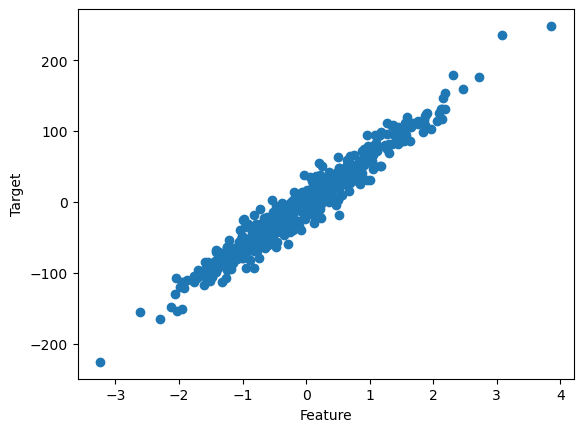

In [2]:
import matplotlib.pyplot as plt

plt.scatter(X, y)
plt.xlabel("Feature")
plt.ylabel("Target")
plt.show()

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [5]:
print(model.coef_)
print(model.intercept_)

[63.3315884]
-0.7729584534834184


In [6]:
predictions = model.predict(X_test)

In [7]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y_test,
    predictions
)

In [8]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    y_test,
    predictions
)

In [9]:
import numpy as np

rmse = np.sqrt(mse)

In [10]:
from sklearn.metrics import r2_score

r2 = r2_score(
    y_test,
    predictions
)

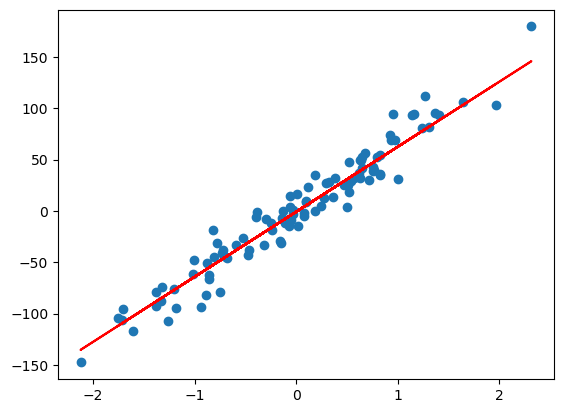

In [11]:
plt.scatter(X_test, y_test)

plt.plot(
    X_test,
    predictions,
    color='red'
)

plt.show()

In [12]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

X = housing.data
y = housing.target

In [13]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [14]:
predictions = model.predict(X_test)

In [15]:
for name, coef in zip(
    housing.feature_names,
    model.coef_
):
    print(name, coef)

MedInc 63.331588403987965


In [16]:
import joblib

joblib.dump(
    model,
    "linear_model.pkl"
)

['linear_model.pkl']

In [ ]:
%pip install fastapi
from fastapi import FastAPI
import joblib

app = FastAPI()

model = joblib.load(
    "linear_model.pkl"
)

@app.post("/predict")
def predict(features: list):

    result = model.predict(
        [features]
    )

    return {
        "prediction":
        float(result[0])
    }